# ۴.۱۰ تحلیل اختصاصی متغیرهای خارجی

بند ۴.۱۰ از WBS (`doc/WBS-food-demand-forecasting.md`). هدف: بررسی رابطه‌ی هرکدام از متغیرهای بیرونی (دما، AQI، بارش، تعطیلات، رمضان/نوروز) با نرخ عدم‌دریافت $\\rho$ = NoRecv/Res، **پس از کنترل روز هفته (DayOfWeek) و سلف (RestaurantName)** — طبق دستور صریح WBS، بدون این کنترل نتیجه‌گیری معتبر نیست (ممکن است صرفاً بازتاب اینکه فلان سلف بیشتر در فصل سرد فعال بوده باشد، نه اثر واقعی دما).

**روش کنترل:** برای هر ردیف، میانگین گروه (DayOfWeek, RestaurantName) از $\\rho$ کم می‌شود؛ باقیمانده (`rho_resid`) دیگر اثر ثابت سلف و روز هفته را ندارد و برای بررسی اثر متغیر بیرونی استفاده می‌شود. برای دما علاوه‌براین یک مدل OLS چندگانه (`rho ~ C(DayOfWeek) + C(RestaurantName) + temp + temp²`) هم برازش می‌شود تا معناداری آماری ضریب دما مستقیماً بررسی شود.

**⚠️ محدودیت مهم:** ستون‌های هواشناسی (`temp_*`, `aqi_us_*`, ...) در این فایل مقدار **واقعی همان روز** هستند. استفاده از آن‌ها در این نوت‌بوک برای کشف رابطه کاملاً مجاز است (این دقیقاً هدف EDA است)، ولی **هیچ نتیجه‌ی این نوت‌بوک به‌معنای «این ستون خام را در فاز ۵ به مدل بدهید» نیست** — در لحظه‌ی تصمیم (۱۵:۰۰ یا ۲۳:۰۰ روز $d-1$) دمای واقعی روز $d$ هنوز معلوم نیست؛ هر فیچر عملیاتی باید lag-1/lag-2 یا پیش‌بینی هواشناسی باشد (طبق `AGENTS.md`، قاعده‌ی برش اطلاعاتی).

**pygam نصب نیست** — طبق تعریف کار، به‌جای GAM از رگرسیون چندجمله‌ای درجه ۲ (و برای بررسی استحکام، درجه ۳) به‌عنوان جایگزین استفاده می‌شود.

خروجی‌ها:
- نمودارها → `reports/figures/4.10_*.png`
- یافته‌های نهایی (کدهای F7.x) → `doc/eda/round1/S7_external_variables.md`
- کد کمکی قابل‌استفاده‌ی مجدد → `src/eda_lib/external_var_helpers.py` (این نوت‌بوک به `src/` موجود دست نمی‌زند)

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scikit_posthocs as sp

from src.config import FIGURES_DIR, set_global_seed
from src.viz_fa import setup as setup_fa, fa
from src.eda_lib.external_var_helpers import (
    load_merged_dataset,
    add_group_residual,
    ols_quadratic_control,
    binscatter,
    lowess_curve,
    mannwhitney_report,
    kruskal_report,
    holiday_offset_table,
)

set_global_seed()
setup_fa()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.width', 120)

df = load_merged_dataset()
df = add_group_residual(df, target='rho', group_cols=['DayOfWeek', 'RestaurantName'], out_col='rho_resid')
print(df.shape)
df[['date_gregorian', 'Meal', 'RestaurantName', 'rho', 'rho_resid', 'temp_mean', 'aqi_us_mean', 'precip_cat', 'is_ramadan']].head()


(7591, 68)


,date_gregorian,Meal,RestaurantName,rho,rho_resid,temp_mean,aqi_us_mean,precip_cat,is_ramadan
0,2023-11-22,dinner,ابوریحان,0.016667,-0.054552,5.56,84.54,dry,False
1,2023-11-22,dinner,ابوریحان,0.031250,-0.039969,5.56,84.54,dry,False
2,2023-11-22,dinner,ساختمان 6,0.064885,-0.029692,5.56,84.54,dry,False
3,2023-11-22,dinner,ساختمان 6,0.063521,-0.031056,5.56,84.54,dry,False
4,2023-11-22,dinner,ساختمان 71و72,0.091335,-0.079970,5.56,84.54,dry,False


## ۱. دما — خطی است یا U-شکل؟

بررسی با دو روش مکمل: (الف) binscatter + LOWESS روی باقیمانده‌ی $\\rho$ پس از کنترل dow+restaurant، (ب) OLS چندگانه با جمله‌ی درجه‌دوم (و درجه‌سوم برای بررسی استحکام نتیجه).

In [2]:
# OLS quadratic و cubic (بررسی استحکام)
ols_deg2 = ols_quadratic_control(df, 'temp_mean', degree=2)
ols_deg3 = ols_quadratic_control(df, 'temp_mean', degree=3)

print('--- OLS درجه ۲ (rho ~ dow + restaurant + temp + temp^2) ---')
print(ols_deg2.params.filter(like='_var_c'))
print(ols_deg2.pvalues.filter(like='_var_c'))
print('R^2 کل مدل:', round(ols_deg2.rsquared, 4))

print('--- OLS درجه ۳ (بررسی استحکام) ---')
print(ols_deg3.params.filter(like='_var_c'))
print(ols_deg3.pvalues.filter(like='_var_c'))


--- OLS درجه ۲ (rho ~ dow + restaurant + temp + temp^2) ---
_var_c      -0.000363
_var_c_p2   -0.000037
dtype: float64
_var_c       0.028103
_var_c_p2    0.115957
dtype: float64
R^2 کل مدل: 0.2227
--- OLS درجه ۳ (بررسی استحکام) ---
_var_c      -0.000453
_var_c_p2   -0.000039
_var_c_p3    0.000001
dtype: float64
_var_c       0.194632
_var_c_p2    0.114376
_var_c_p3    0.768962
dtype: float64


/tmp/ipykernel_429224/3575207438.py:24: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  fig.tight_layout()
/tmp/ipykernel_429224/3575207438.py:25: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  fig.savefig(FIGURES_DIR / '4.10_temp_binscatter_lowess.png', dpi=150)
/home/mvajhi/code/new_project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  fig.canvas.print_figure(bytes_io, **kw)


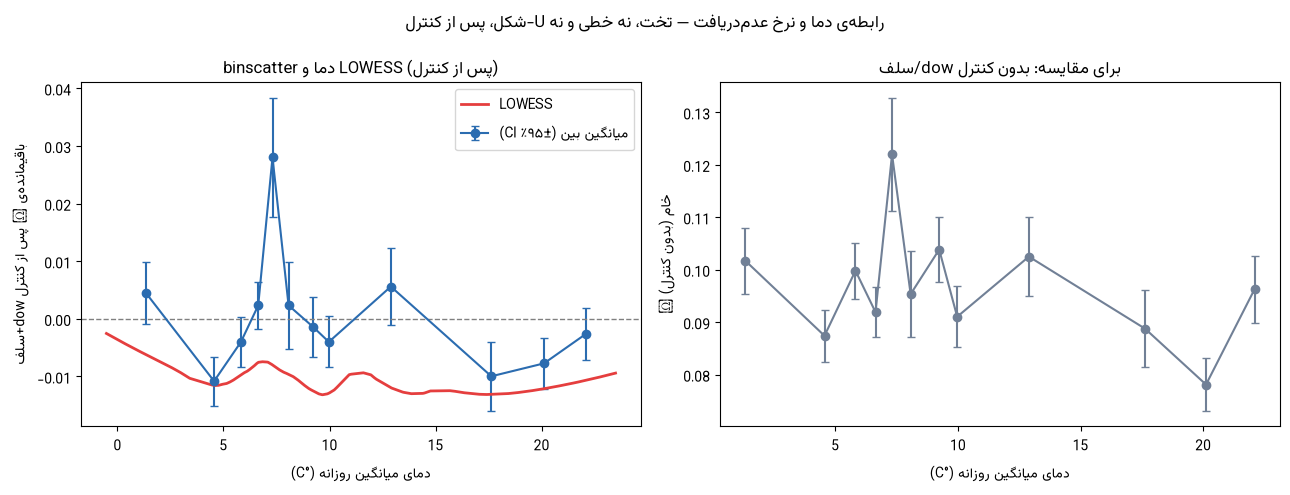

In [3]:
# binscatter + LOWESS روی rho_resid (باقیمانده‌ی پس از کنترل dow+restaurant)
bin_temp = binscatter(df, 'temp_mean', 'rho_resid', n_bins=12)
lx, ly = lowess_curve(df['temp_mean'], df['rho_resid'], frac=0.4)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.errorbar(bin_temp['x_mean'], bin_temp['y_mean'], yerr=1.96 * bin_temp['y_sem'], fmt='o-', color='#2b6cb0', capsize=3, label=fa('میانگین بین (±۹۵٪ CI)'))
ax.plot(lx, ly, color='#e53e3e', lw=2, label='LOWESS')
ax.axhline(0, color='gray', lw=1, ls='--')
ax.set_xlabel(fa('دمای میانگین روزانه (°C)'))
ax.set_ylabel(fa('باقیمانده‌ی ρ پس از کنترل dow+سلف'))
ax.set_title(fa('binscatter دما و LOWESS (پس از کنترل)'))
ax.legend()

ax = axes[1]
bin_temp_raw = binscatter(df, 'temp_mean', 'rho', n_bins=12)
ax.errorbar(bin_temp_raw['x_mean'], bin_temp_raw['y_mean'], yerr=1.96 * bin_temp_raw['y_sem'], fmt='o-', color='#718096', capsize=3)
ax.set_xlabel(fa('دمای میانگین روزانه (°C)'))
ax.set_ylabel(fa('ρ خام (بدون کنترل)'))
ax.set_title(fa('برای مقایسه: بدون کنترل dow/سلف'))

fig.suptitle(fa('رابطه‌ی دما و نرخ عدم‌دریافت — تخت، نه خطی و نه U-شکل، پس از کنترل'))
fig.tight_layout()
fig.savefig(FIGURES_DIR / '4.10_temp_binscatter_lowess.png', dpi=150)
plt.show()


**نتیجه‌گیری دما:** پس از کنترل dow+سلف، هم binscatter و هم منحنی LOWESS حول صفر نوسان می‌کنند و **هیچ الگوی یکنواخت خطی یا U-شکل قابل‌اتکایی** دیده نمی‌شود. در مدل OLS درجه‌۲، ضریب جمله‌ی خطی دما در مرز معناداری (p≈۰.۰۳) با علامت منفی (دمای بالاتر ↔ عدم‌دریافت اندکی کمتر) است اما اندازه‌اثر ناچیز است (برای کل بازه‌ی ۲۴ درجه‌ای دما، تغییر پیش‌بینی‌شده در ρ در حد چند صدم است)؛ ضریب جمله‌ی درجه‌۲ معنادار نیست (p≈۰.۱۲) — یعنی شواهد کافی برای U-شکل بودن رابطه نیست. مهم‌تر: با افزودن جمله‌ی درجه‌۳ (بررسی استحکام)، حتی همان ضریب خطی مرزی هم دیگر معنادار نمی‌ماند (p≈۰.۲) — نشانه‌ی اینکه اثر خطی مرزی robust به specification نیست.

**جمع‌بندی:** بهترین توصیف رابطه‌ی دما-ρ در این داده، **تخت (flat/negligible)** است، نه خطی قوی و نه U-شکل. R² کل مدل OLS (شامل dummy های dow و سلف) حدود ۰.۲۲ است که عمدتاً از اثرات ثابت سلف/روز هفته می‌آید، نه دما.

⚠️ یادآوری leakage: این نتیجه‌گیری «دما فیچر خوبی نیست» مبتنی بر دمای **واقعی همان روز** است؛ حتی اگر در فاز ۵ دما (به‌صورت lag-1/پیش‌بینی) بررسی شود، این تحلیل نشان می‌دهد انتظار نباید بالا باشد.

## ۲. AQI — آیا اثر آستانه‌ای دارد؟

بررسی با binscatter (خطوط عمودی روی آستانه‌های ۱۰۰/۱۵۰/۲۰۰) و آزمون Mann-Whitney بین AQI<۱۵۰ و AQI≥۱۵۰، هم روی $\\rho$ خام و هم روی باقیمانده‌ی پس از کنترل dow+سلف.

In [4]:
print('AQI (aqi_us_mean) توصیف:')
print(df['aqi_us_mean'].describe())

mw_raw = mannwhitney_report(
    df.loc[df['aqi_us_mean'] < 150, 'rho'], df.loc[df['aqi_us_mean'] >= 150, 'rho'],
    'AQI<150 (خام)', 'AQI>=150 (خام)',
)
mw_ctrl = mannwhitney_report(
    df.loc[df['aqi_us_mean'] < 150, 'rho_resid'], df.loc[df['aqi_us_mean'] >= 150, 'rho_resid'],
    'AQI<150 (کنترل‌شده)', 'AQI>=150 (کنترل‌شده)',
)
print('--- Mann-Whitney روی ρ خام ---')
print(pd.Series(mw_raw))
print('--- Mann-Whitney روی باقیمانده (پس از کنترل dow+سلف) ---')
print(pd.Series(mw_ctrl))

AQI (aqi_us_mean) توصیف:
count    7591.000000
mean      122.790539
std        32.694910
min        66.710000
25%        90.040000
50%       118.420000
75%       156.040000
max       174.750000
Name: aqi_us_mean, dtype: float64
--- Mann-Whitney روی ρ خام ---
label_a           AQI<150 (خام)
label_b          AQI>=150 (خام)
n_a                        4891
n_b                        2700
median_a               0.079365
median_b               0.081081
U                     6446320.5
p_value                0.086788
rank_biserial          0.023706
dtype: object
--- Mann-Whitney روی باقیمانده (پس از کنترل dow+سلف) ---
label_a           AQI<150 (کنترل‌شده)
label_b          AQI>=150 (کنترل‌شده)
n_a                              4891
n_b                              2700
median_a                    -0.011049
median_b                    -0.010087
U                           6536764.0
p_value                       0.46968
rank_biserial                0.010009
dtype: object


/tmp/ipykernel_429224/432509452.py:12: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  fig.tight_layout()
/tmp/ipykernel_429224/432509452.py:13: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  fig.savefig(FIGURES_DIR / "4.10_aqi_threshold.png", dpi=150)
/home/mvajhi/code/new_project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  fig.canvas.print_figure(bytes_io, **kw)


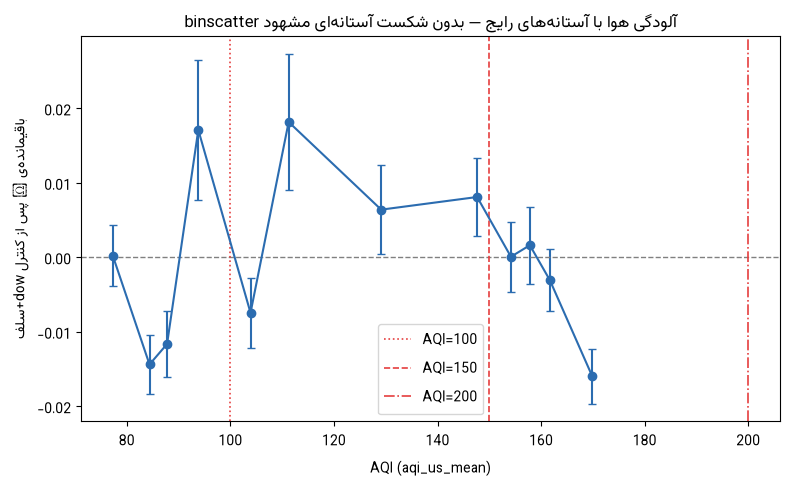

In [5]:
bin_aqi = binscatter(df, "aqi_us_mean", "rho_resid", n_bins=12)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(bin_aqi["x_mean"], bin_aqi["y_mean"], yerr=1.96 * bin_aqi["y_sem"], fmt="o-", color="#2b6cb0", capsize=3)
ax.axhline(0, color="gray", lw=1, ls="--")
for thr, style in zip([100, 150, 200], [":", "--", "-."]):
    ax.axvline(thr, color="#e53e3e", lw=1.2, ls=style, label=f"AQI={thr}")
ax.set_xlabel("AQI (aqi_us_mean)")
ax.set_ylabel(fa("باقیمانده‌ی ρ پس از کنترل dow+سلف"))
ax.set_title(fa("binscatter آلودگی هوا با آستانه‌های رایج — بدون شکست آستانه‌ای مشهود"))
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "4.10_aqi_threshold.png", dpi=150)
plt.show()

**نتیجه‌گیری AQI:** نه در binscatter و نه در آزمون Mann-Whitney (نه روی ρ خام و نه روی باقیمانده‌ی کنترل‌شده) شکست آستانه‌ای در ۱۵۰ دیده نمی‌شود؛ هر دو آزمون غیرمعنادار یا نزدیک مرز با اندازه‌اثر rank-biserial ناچیز (~۰.۰۱–۰.۰۲) هستند. توجه: در بازه‌ی داده‌ی قفل‌شده (۲۰۲۳-۱۱-۲۲ تا ۲۰۲۴-۰۵-۲۱) هیچ روزی AQI میانگین بالای ۲۰۰ ندارد، پس آستانه‌ی ۲۰۰ در این داده قابل‌آزمون نیست. کنترل dow+سلف در این مورد نتیجه را عوض نکرد (هر دو نسخه غیرمعنادارند) — نشانه‌ی خوبی که نتیجه واقعاً «بدون اثر» است، نه یک اثر واقعی که کنترل آن را پوشانده باشد.

⚠️ یادآوری leakage: مثل دما، AQI هم مقدار واقعی همان روز است؛ فیچر عملیاتی فاز ۵ باید lag-1/۲ یا پیش‌بینی باشد — که با نبود اثر همزمان، انتظار برای اثر فیچر با تأخیر هم پایین می‌آید.

## ۳. بارش — نوع (باران/برف) مهم‌تر است یا مقدار؟

`precip_cat` (ساخته‌شده در `load_merged_dataset`): `snow` اگر `snowfall_sum>0`، وگرنه `rain` اگر `rain_sum>0`، وگرنه `dry`. مقایسه‌ی سه‌گروهی روی باقیمانده‌ی کنترل‌شده با Kruskal-Wallis + Dunn post-hoc (تصحیح FDR-BH).

In [6]:
print(df['precip_cat'].value_counts())
print(df.groupby('precip_cat')['date_gregorian'].nunique())

kw = kruskal_report({cat: df.loc[df['precip_cat'] == cat, 'rho_resid'] for cat in ['dry', 'rain', 'snow']})
print('Kruskal-Wallis:', {k: v for k, v in kw.items() if k != 'groups'})
print('n per group:', kw['groups'])

dunn = sp.posthoc_dunn(df, val_col='rho_resid', group_col='precip_cat', p_adjust='fdr_bh')
print('Dunn post-hoc (p تصحیح‌شده FDR-BH):')
print(dunn.round(4))

precip_cat
dry     5176
rain    1884
snow     531
Name: count, dtype: int64
precip_cat
dry     93
rain    37
snow    12
Name: date_gregorian, dtype: int64
Kruskal-Wallis: {'medians': {'dry': np.float64(-0.011815305063313034), 'rain': np.float64(-0.009390805674360386), 'snow': np.float64(-0.005184985252182028)}, 'H': np.float64(15.60164795587731), 'p_value': np.float64(0.00040939750545087726), 'epsilon_squared': np.float64(0.0017925208165362823)}
n per group: {'dry': 5176, 'rain': 1884, 'snow': 531}
Dunn post-hoc (p تصحیح‌شده FDR-BH):
         dry    rain    snow
dry   1.0000  0.0363  0.0011
rain  0.0363  1.0000  0.0389
snow  0.0011  0.0389  1.0000


/tmp/ipykernel_429224/2652568155.py:12: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  fig.tight_layout()
/tmp/ipykernel_429224/2652568155.py:13: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  fig.savefig(FIGURES_DIR / "4.10_precip_type.png", dpi=150)
/home/mvajhi/code/new_project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  fig.canvas.print_figure(bytes_io, **kw)


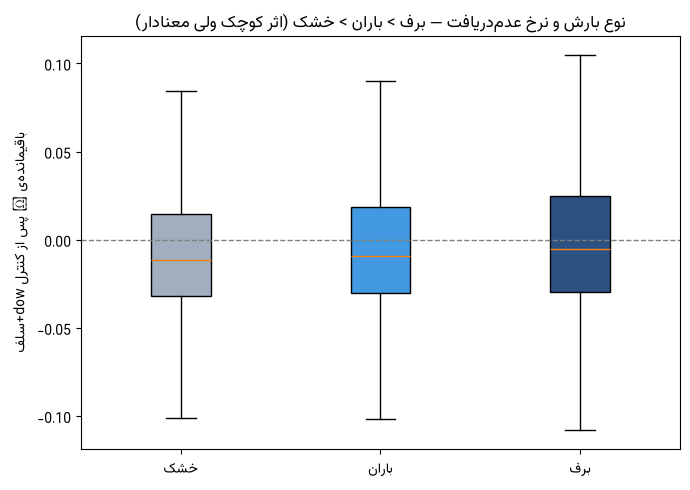

In [7]:
order = ["dry", "rain", "snow"]
labels_fa = [fa("خشک"), fa("باران"), fa("برف")]
data_by_cat = [df.loc[df["precip_cat"] == c, "rho_resid"].values for c in order]

fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot(data_by_cat, tick_labels=labels_fa, showfliers=False, patch_artist=True)
for patch, color in zip(bp["boxes"], ["#a0aec0", "#4299e1", "#2c5282"]):
    patch.set_facecolor(color)
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_ylabel(fa("باقیمانده‌ی ρ پس از کنترل dow+سلف"))
ax.set_title(fa("نوع بارش و نرخ عدم‌دریافت — برف > باران > خشک (اثر کوچک ولی معنادار)"))
fig.tight_layout()
fig.savefig(FIGURES_DIR / "4.10_precip_type.png", dpi=150)
plt.show()

**نتیجه‌گیری بارش:** Kruskal-Wallis معنادار است (p<۰.۰۰۱) اما اندازه‌اثر (ε²) بسیار کوچک است (~۰.۰۰۲) — یعنی تفاوت آماری معنادار ولی عملاً کوچک، که با N بزرگ (۷۵۹۱ ردیف) قابل‌انتظار است. میانه‌ی باقیمانده به ترتیب `dry < rain < snow` است (روزهای برفی بیشترین نرخ عدم‌دریافت را دارند). آزمون Dunn نشان می‌دهد **هر سه جفت** پس از تصحیح FDR-BH معنادارند، اما snow-dry قوی‌تر از دو جفت دیگر است. **نتیجه: نوع بارش (برف به‌طور خاص) از مقدار خام بارش مهم‌تر به‌نظر می‌رسد** — احتمالاً چون برف (نه فقط باران) با اختلال در تردد/سرویس‌دهی دانشگاه مرتبط است؛ نمونه‌ی روزهای برفی محدود است (۱۲ روز، ۵۳۱ ردیف) پس این یافته باید محتاطانه تفسیر شود.